# Knowledge Graph (KG) + Graph Neural Network (GNN) Implementation for On-device Predictive Model

This approach is an alternative to the XGBoost + LSTM-based pipeline. Here, KG is utilized to map all the relationships between the various entities. For example:
  
A user ---uses--> a device.

These types of data mappings are very well suited for the given dataset.

### Dataset Used:
Samsung SmartThings Internet of Things (IoT) datasets. https://github.com/snudatalab/smartsense


## The main pipeline:
  
SmartThings Logs -> Data Preprocessing -> KG construction -> Graph Embedding / GNN Model -> Device Priority Prediction -> Ranked Device List


---
## 1. Setup and Imports

In [2]:
!pip install pandas
!pip install networkx
!pip install node2vec
!pip install tensorflow
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [22 lines of output]
      + C:\Python313\python.exe C:\Users\Dell\AppData\Local\Temp\pip-install-j5fzbhr_\numpy_1e812ae1381c4a4485453c8fb0f06d1d\vendored-meson\meson\meson.py setup C:\Users\Dell\AppData\Local\Temp\pip-install-j5fzbhr_\numpy_1e812ae1381c4a4485453c8fb0f06d1d C:\Users\Dell\AppData\Local\Temp\pip-install-j5fzbhr_\numpy_1e812ae1381c4a4485453c8fb0f06d1d\.mesonpy-xt9mlf64 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\Dell\AppData\Local\Temp\pip-install-j5fzbhr_\numpy_1e812ae1381c4a4485453c8fb0f06d1d\.mesonpy-xt9mlf64\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\Dell\AppData\Local\Temp\pip-install-j5fzbhr_\numpy_1e812ae1381c4a4485453c8fb0f06d1d
      Build dir: C:\Users\Dell\AppData\Local\Temp\pip-install-j5fzbhr_\numpy_1e812ae1381c4a4485453c8fb0f06d1d\.me

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
  Using cached rich

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import pickle
import tensorflow as tf

from node2vec import Node2Vec
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'networkx'

---
## 2. Load the SmartThings Dataset

In [15]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
with open("data/kr/trn_instance_10.pkl", "rb") as f: # fr training example taken
    data = pickle.load(f)

print(len(data))
print(data[0])

199786
[[  4   7  33   1 245]
 [  5   3  33   1 245]
 [  5   4  33   0 244]
 [  6   0  33   1 245]
 [  6   4  33   0 244]
 [  6   7  33   1 245]
 [  0   1  33   0 244]
 [  0   3  33   1 245]
 [  0   4  33   0 244]
 [  1   3  33   1 245]]


Here, each action is:

    [day_of_week, hour, device, control, device_control]

---
## 3. Data Preprocessing

Here we flatten each sequence and store them as dictionaries for the Knowledge Graph.

In [4]:
records = []

for seq in data:
    for action in seq:
        records.append({
            "day": action[0],
            "hour": action[1],
            "device": action[2],
            "control": action[3],
            "device_control": action[4]
        })

df = pd.DataFrame(records)

df.head()

,day,hour,device,control,device_control
0,4,7,33,1,245
1,5,3,33,1,245
2,5,4,33,0,244
3,6,0,33,1,245
4,6,4,33,0,244


---
## 4. Building the Knowledge Graph

In [5]:
G = nx.Graph()

for _, row in df.iterrows():

    device = f"device_{row['device']}"
    control = f"control_{row['control']}"
    hour = f"hour_{row['hour']}"
    day = f"day_{row['day']}"

    G.add_edge(device, control)
    G.add_edge(device, hour)
    G.add_edge(device, day)

In [6]:
print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))

Nodes: 81
Edges: 816


##5. Graph Visualization

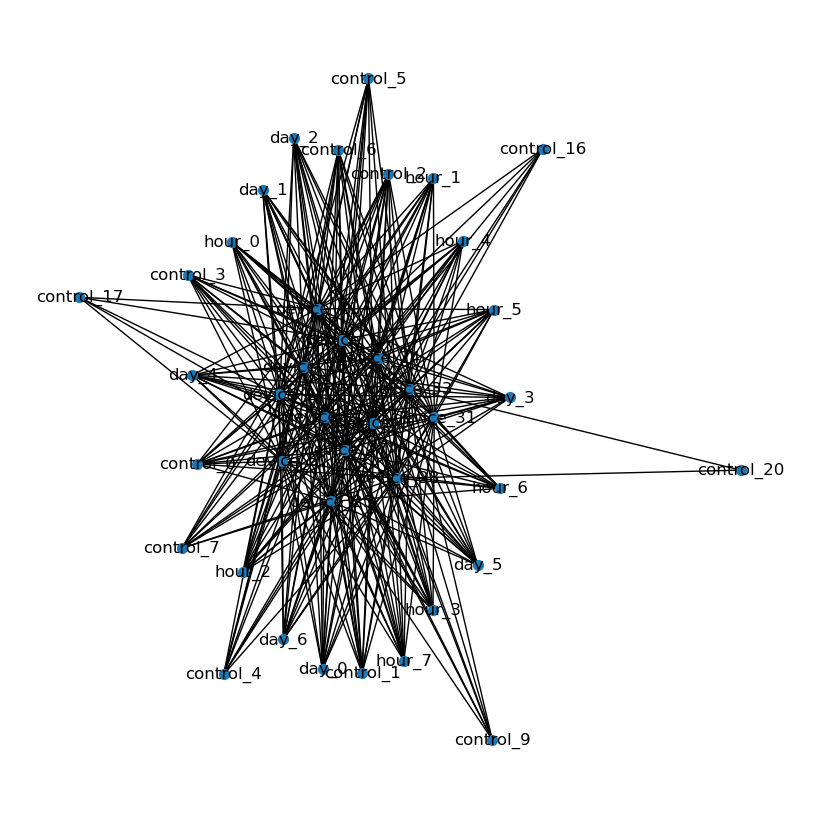

In [7]:
import matplotlib.pyplot as plt

sub_nodes = list(G.nodes)[:40]
subgraph = G.subgraph(sub_nodes)

plt.figure(figsize=(8,8))
nx.draw(subgraph, with_labels=True, node_size=50)
plt.show()

## 6. Generate Graph Embeddings

In [8]:
node2vec = Node2Vec(
    G,
    dimensions=32,
    walk_length=10,
    num_walks=100,
    workers=2
)

node2vec_model = node2vec.fit(window=5, min_count=1)

Computing transition probabilities:   0%|          | 0/81 [00:00<?, ?it/s]

Generating walks (CPU: 2): 100%|██████████| 50/50 [00:00<00:00, 100.36it/s]


## 7. Extract Device Embeddings

In [9]:
device_embeddings = {}

for node in G.nodes():
    if node.startswith("device_"):
        device_embeddings[node] = node2vec_model.wv[node]

print(len(device_embeddings))

27


In [10]:
num_devices = df["device"].nunique()
embedding_dim = 32

device_embedding_matrix = np.zeros((num_devices, embedding_dim))

for node, emb in device_embeddings.items():
    device_id = int(node.split("_")[1])
    if device_id < num_devices:
        device_embedding_matrix[device_id] = emb



## 8. Create Device Priority Dataset

In [11]:
from sklearn.preprocessing import LabelEncoder

X = []
y = []

for seq in data:

    input_seq = seq[:9]     # first 9 actions
    target = seq[9][2]      # device of the 10th action

    X.append(input_seq)
    y.append(target)

X = np.array(X)
y = np.array(y)


# to normalize y
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
sequence_length = 3

X_seq = []
y_seq = []

devices = df["device"].values

for i in range(len(devices) - sequence_length):
    X_seq.append(devices[i:i+sequence_length])
    y_seq.append(devices[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

## 9. Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 10. Build Keras Ranking Model

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(9,5)),
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(num_devices, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
    ]
)


/home/amit/anaconda3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/amit/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773211870.446614   19504 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773211870.447775   20368 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expec

In [ ]:
inputs = tf.keras.Input(shape=(sequence_length,))

embedding_layer = tf.keras.layers.Embedding(
    input_dim=num_devices,
    output_dim=embedding_dim,
    weights=[device_embedding_matrix],
    trainable=False
)

x = embedding_layer(inputs)

x = tf.keras.layers.MultiHeadAttention(
    num_heads=4,
    key_dim=embedding_dim
)(x, x)

x = tf.keras.layers.GlobalAveragePooling1D()(x)

x = tf.keras.layers.Dense(64, activation="relu")(x)

outputs = tf.keras.layers.Dense(num_devices, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
    ]
)

##11. Train Model

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Save the best model based on validation loss
checkpoint = ModelCheckpoint(
    "best_model.h5",          # file name
    monitor="val_loss",       # metric to watch
    save_best_only=True,      # only save when model improves
    mode="min",               # lower loss is better
    verbose=1
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint]
)


model.evaluate(X_test, y_test)

Epoch 1/10
3982/3996 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7795 - loss: 0.8723 - sparse_top_k_categorical_accuracy: 0.8986
Epoch 1: val_loss improved from None to 0.87794, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7795 - loss: 0.8707 - sparse_top_k_categorical_accuracy: 0.8986 - val_accuracy: 0.7785 - val_loss: 0.8779 - val_sparse_top_k_categorical_accuracy: 0.8975
Epoch 2/10
3988/3996 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7800 - loss: 0.8679 - sparse_top_k_categorical_accuracy: 0.9000
Epoch 2: val_loss improved from 0.87794 to 0.86992, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7808 - loss: 0.8684 - sparse_top_k_categorical_accuracy: 0.8992 - val_accuracy: 0.7809 - val_loss: 0.8699 - val_sparse_top_k_categorical_accuracy: 0.8993
Epoch 3/10
3994/3996 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7822 - loss: 0.8671 - sparse_top_k_categorical_accuracy: 0.8996
Epoch 3: val_loss improved from 0.86992 to 0.85006, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7826 - loss: 0.8648 - sparse_top_k_categorical_accuracy: 0.9002 - val_accuracy: 0.7784 - val_loss: 0.8501 - val_sparse_top_k_categorical_accuracy: 0.9024
Epoch 4/10
3984/3996 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7826 - loss: 0.8648 - sparse_top_k_categorical_accuracy: 0.8996
Epoch 4: val_loss improved from 0.85006 to 0.84170, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7824 - loss: 0.8633 - sparse_top_k_categorical_accuracy: 0.9005 - val_accuracy: 0.7855 - val_loss: 0.8417 - val_sparse_top_k_categorical_accuracy: 0.9012
Epoch 5/10
3993/3996 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7813 - loss: 0.8634 - sparse_top_k_categorical_accuracy: 0.9010
Epoch 5: val_loss did not improve from 0.84170
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7823 - loss: 0.8612 - sparse_top_k_categorical_accuracy: 0.9010 - val_accuracy: 0.7893 - val_loss: 0.9070 - val_sparse_top_k_categorical_accuracy: 0.8860
Epoch 6/10
3988/3996 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7842 - loss: 0.8526 - sparse_top_k_categorical_accuracy: 0.9024
Epoch 6: val_loss did not improve from 0.84170
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7828 - loss: 0.8582 - sparse_top_k_categorical_accuracy: 0.9016 - val_accuracy: 0.7886 - val_loss: 0.8428 - val


Epoch 7: finished saving model to best_model.h5
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7839 - loss: 0.8551 - sparse_top_k_categorical_accuracy: 0.9019 - val_accuracy: 0.7834 - val_loss: 0.8413 - val_sparse_top_k_categorical_accuracy: 0.9027
Epoch 8/10
3994/3996 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7838 - loss: 0.8557 - sparse_top_k_categorical_accuracy: 0.9011
Epoch 8: val_loss did not improve from 0.84126
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7841 - loss: 0.8527 - sparse_top_k_categorical_accuracy: 0.9019 - val_accuracy: 0.7916 - val_loss: 0.8562 - val_sparse_top_k_categorical_accuracy: 0.8999
Epoch 9/10
3993/3996 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7846 - loss: 0.8516 - sparse_top_k_categorical_accuracy: 0.9025
Epoch 9: val_loss improved from 0.84126 to 0.83568, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7834 - loss: 0.8547 - sparse_top_k_categorical_accuracy: 0.9019 - val_accuracy: 0.7888 - val_loss: 0.8357 - val_sparse_top_k_categorical_accuracy: 0.9030
Epoch 10/10
3992/3996 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7847 - loss: 0.8484 - sparse_top_k_categorical_accuracy: 0.9036
Epoch 10: val_loss did not improve from 0.83568
3996/3996 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7837 - loss: 0.8539 - sparse_top_k_categorical_accuracy: 0.9025 - val_accuracy: 0.7918 - val_loss: 0.8482 - val_sparse_top_k_categorical_accuracy: 0.9018
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7882 - loss: 0.8643 - sparse_top_k_categorical_accuracy: 0.9006


[0.8642914891242981, 0.7881776094436646, 0.9005956053733826]

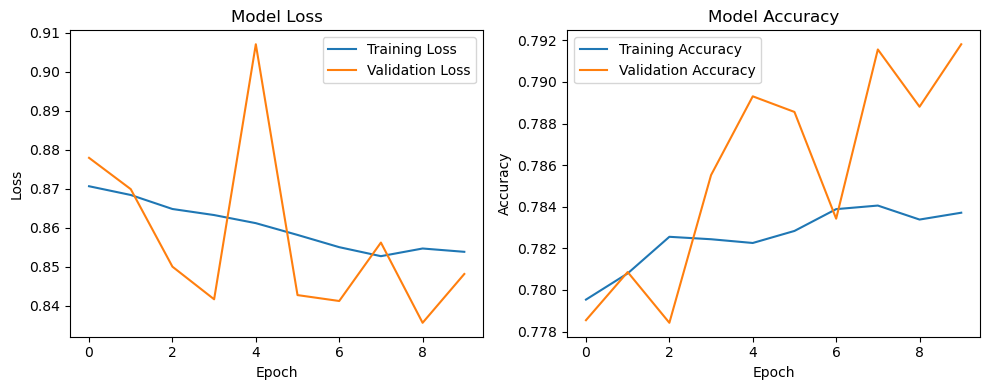

In [18]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Training & Validation Accuracy (if accuracy is included in model.compile)
if 'accuracy' in history.history:
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

plt.tight_layout()
plt.show()

In [50]:
print(X_train.shape)
print(y_train.shape)

print(np.isnan(X_train).any())
print(np.isinf(X_train).any())

print(y_train.max())
print(y_train.min())

(159828, 9, 5)
(159828,)
False
False
26
0


## 12. Predict Device Priority

In [15]:
scores = model.predict(X)

devices = df["device"].unique()

ranking = sorted(
    zip(devices, scores),
    key=lambda x: x[1].max(),
    reverse=True
)

print("Device Priority Ranking")

for r in ranking[:10]:
    print(r)

6244/6244 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
Device Priority Ranking
(9, array([1.8893456e-03, 6.8517313e-03, 2.9247941e-03, 6.1048406e-05,
       3.2618133e-05, 2.0212041e-05, 6.6818495e-05, 6.9772091e-04,
       1.5117193e-04, 1.3001892e-04, 5.1493186e-07, 6.1913789e-04,
       5.2225555e-04, 1.3679625e-04, 1.0513951e-04, 3.9262799e-04,
       3.8915590e-04, 2.0416122e-04, 2.4100884e-05, 3.1309645e-03,
       2.0666379e-02, 1.4984052e-04, 7.4478076e-04, 1.1350206e-03,
       9.5773178e-01, 9.3795120e-04, 2.8397198e-04], dtype=float32))
(33, array([1.9959291e-03, 7.3242579e-03, 3.2215531e-03, 6.7538145e-05,
       3.5677440e-05, 2.3386705e-05, 7.2107403e-05, 7.3955982e-04,
       1.6431589e-04, 1.4124662e-04, 5.5488169e-07, 6.6260179e-04,
       5.5957382e-04, 1.4293069e-04, 1.0815357e-04, 4.0361553e-04,
       3.9811176e-04, 2.1515512e-04, 2.5161293e-05, 3.2783544e-03,
       2.0804843e-02, 1.5393992e-04, 7.2919572e-04, 1.1419695e-03,
       9.5632529e-01, 9.9026575e-04, 2.7474805e-04

##13. Convert To TensorFlow Lite

In [52]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("device_priority_gnn.tflite","wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpu78rg7oq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9, 5), dtype=tf.float32, name='keras_tensor_31')
Output Type:
  TensorSpec(shape=(None, 27), dtype=tf.float32, name=None)
Captures:
  135595699107600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135595699108368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135595699108176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135595699104912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135595699108944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135595699108560: TensorSpec(shape=(), dtype=tf.resource, name=None)
